# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [49]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargar Dataset

In [50]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [51]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- 

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna ... .


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `visitas_mes`
- `compras_mes`
- `nivel_ingreso`
- `gasto_publicidad_dirigida`
- `ingreso_anual`
La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` aparece como float64 pero deberia ser int64 ya que se cuenta la edad como numero entero.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [52]:

# Corregir el tipo de dato

df["edad"] = df["edad"].astype(int)

In [53]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  int64  
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [54]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


Diagnóstico inicial de variables numéricas

- edad — La mayoría de usuarios son adultos, con edades entre 18 y 75 años.
- nivel_ingreso — Existe variabilidad importante en el nivel de ingresos de los clientes.
- visitas_mes — Los usuarios muestran una frecuencia de uso relativamente estable.
- compras_mes — La mayoría realiza pocas compras mensuales, aunque existen usuarios más activos.
- gasto_publicidad_dirigida — El gasto publicitario varía considerablemente entre clientes.
- satisfaccion — La satisfacción promedio es moderadamente positiva.
- miembro_premium — Solo una minoría pertenece al programa premium.
- abandono — La tasa de abandono es cercana al 15%.
- ingreso_anual — Existe alta dispersión en los ingresos generados por cliente.

#### Explorar variables binarias

In [55]:
# Verificar que cada columna tenga únicamente dos valores posibles
columnas_binarias = ['miembro_premium', 'abandono']

for col in columnas_binarias:
    print(f"\nValores únicos en {col}:")
    print(df[col].unique())


Valores únicos en miembro_premium:
[0 1]

Valores únicos en abandono:
[0 1]


Diagnóstico inicial de variables binarias


- miembro_premium — La columna contiene únicamente valores 0 y 1, por lo que la codificación binaria es consistente y válida para análisis correlacionales.
- abandono — La columna también presenta únicamente valores 0 y 1, indicando una variable binaria correctamente estructurada para análisis.

#### Explorar variables categóricas

In [56]:
# Verificar el número de valores únicos por variable categórica
columnas_categoricas = ['id_cliente', 'tipo_dispositivo', 'region']

for col in columnas_categoricas:
    print(f"\nValores únicos en {col}:")
    print(df[col].nunique())


Valores únicos en id_cliente:
15000

Valores únicos en tipo_dispositivo:
3

Valores únicos en region:
4


In [57]:
# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas = ['tipo_dispositivo', 'region']

for col in columnas_categoricas:
    print(f"\nDistribución de {col}:")
    print(df[col].value_counts())


Distribución de tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Distribución de region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64


Diagnóstico inicial de variables categóricas

- id_cliente — Existen 15,000 valores únicos, lo que confirma que cada cliente tiene un identificador individual sin duplicados aparentes.
- tipo_dispositivo — La mayoría de usuarios utiliza dispositivos móviles, lo que sugiere que el tráfico principal de la plataforma proviene de smartphones.
- region — La distribución regional es relativamente balanceada, aunque la región norte concentra la mayor cantidad de usuarios.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.


## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.


### Heatmap

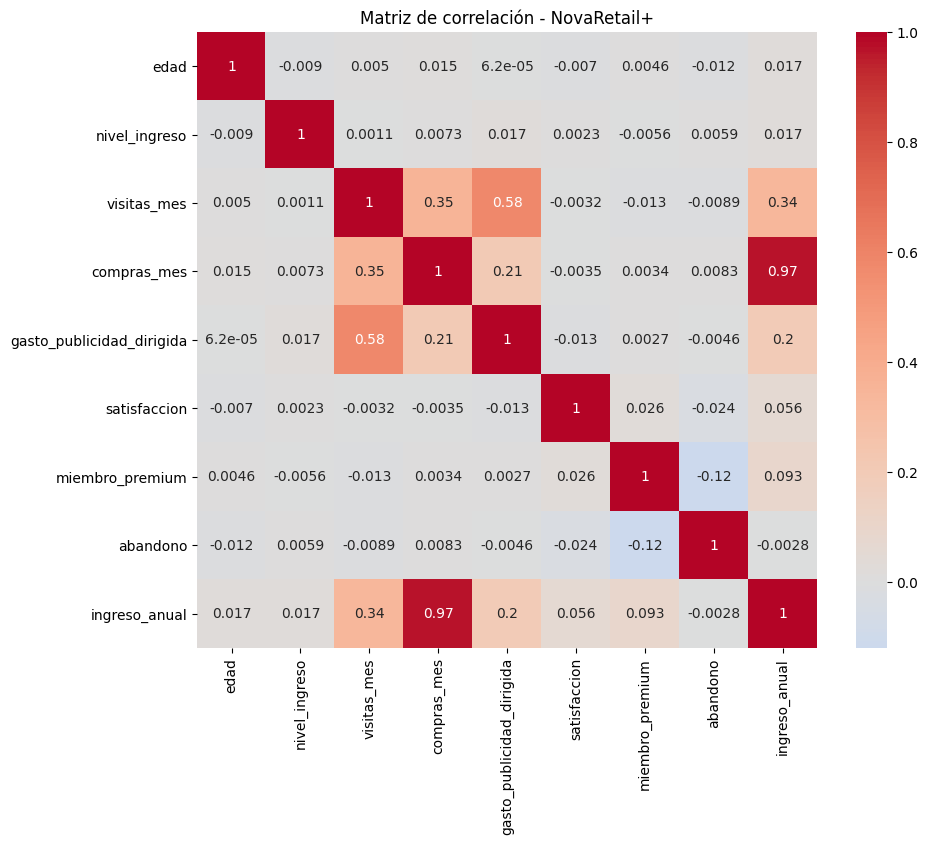

In [58]:
# Visualizar la matriz de correlación para identificar relaciones
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    corr,
    annot = True,
    cmap = "coolwarm",
    center = 0
)

plt.title('Matriz de correlación - NovaRetail+')
plt.show()


**Observaciones generales (Heatmap)**  
- Se observa que la mayoría de las variables tienen correlaciones bajas o cercanas a 0.
- compras_mes vs ingreso_anual (~0.97) → extremadamente alta
- visitas_mes vs gasto_publicidad_dirigida (~0.58) → moderada-alta
- visitas_mes vs compras_mes (~0.35) → moderada
- visitas_mes vs ingreso_anual (~0.34) → moderada

**Observaciones respecto a `ingreso_anual`**  
- Presenta una correlación extremadamente alta con compras_mes (~0.97). Esto sugiere que el ingreso depende casi directamente del número de compras. Podría ser una variable derivada o altamente influenciada por esta.
- Tiene una correlación moderada con visitas_mes (~0.34). Más visitas → más ingresos (relación lógica de conversión).
  
**Relación débil con:**
- nivel_ingreso (~0.017)
- edad (~0.017)
- miembro_premium (~0.093)
- satisfaccion (~0.056)
  
Esto indica que el ingreso no está fuertemente influenciado por variables demográficas, sino más por el comportamiento del usuario


### Scatterplot general


Según los resultados del análisis de correlación, la generación de scatterplots resulta útil, ya que el heatmap identificó relaciones de moderadas a fuertes entre las variables clave.

Esto nos permitirá validar visualmente:

- la forma de la relación,
- posibles patrones no lineales,
- la dispersión,
- y la presencia de valores atípicos.

En concreto, ayudará a confirmar si la correlación extremadamente alta entre las compras mensuales y los ingresos anuales corresponde a una relación consistente o a una posible variable derivada.


### Scatterplot para pares clave

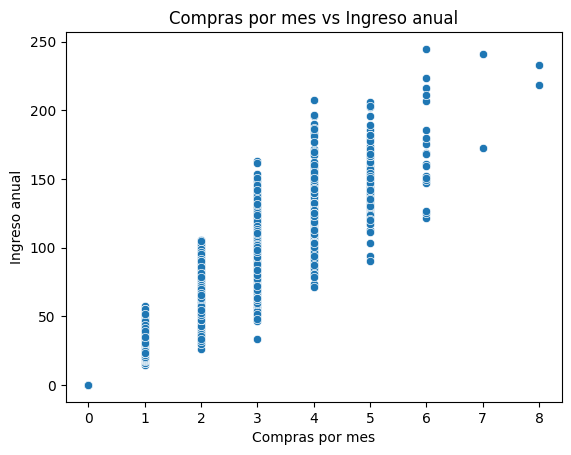

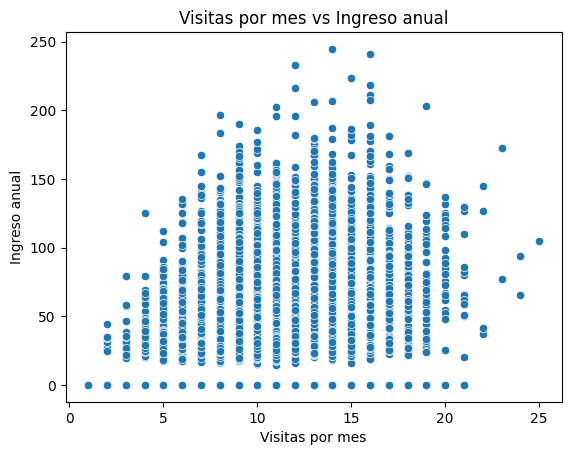

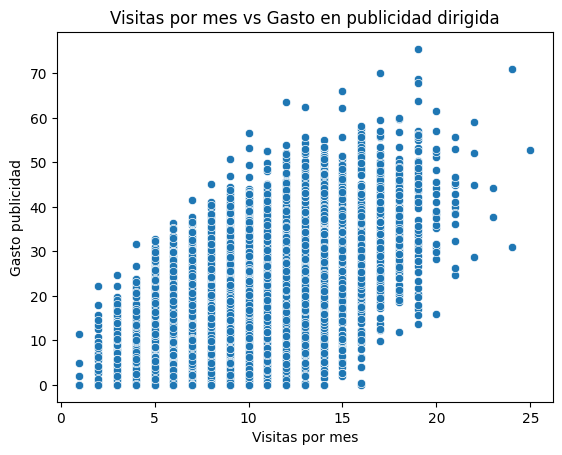

In [59]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# compras_mes vs ingreso_anual

sns.scatterplot(
    data=df,
    x='compras_mes',
    y='ingreso_anual'
)

plt.title('Compras por mes vs Ingreso anual')
plt.xlabel('Compras por mes')
plt.ylabel('Ingreso anual')
plt.show()


# visitas_mes vs ingreso_anual

sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='ingreso_anual'
)

plt.title('Visitas por mes vs Ingreso anual')
plt.xlabel('Visitas por mes')
plt.ylabel('Ingreso anual')
plt.show()


# visitas_mes vs gasto_publicidad_dirigida

sns.scatterplot(
    data=df,
    x='visitas_mes',
    y='gasto_publicidad_dirigida'
)

plt.title('Visitas por mes vs Gasto en publicidad dirigida')
plt.xlabel('Visitas por mes')
plt.ylabel('Gasto publicidad')
plt.show()


**Observaciones iniciales (Scatterplot)**

📈 compras_mes vs ingreso_anual

- Dirección: Positiva clara. A mayor número de compras mensuales, tiende a observarse un mayor ingreso anual

- Dispersión: Baja a media. Los puntos siguen un patrón bastante alineado

- Outliers: Se observan algunos valores altos de ingreso, pero siguen la tendencia general. No parecen atípicos problemáticos.

- Posible colinealidad: Muy alta. Existe una relación muy fuerte entre ambas variables

- Interpretación: Los usuarios con más compras suelen mostrar mayores ingresos, pero esto puede estar influido por otros factores, como: precio promedio de los productos, promociones o descuentos, comportamiento de compra (frecuencia vs ticket alto).


📊 visitas_mes vs ingreso_anual

- Dirección: Positiva débil a moderada. A mayor número de visitas, tiende a haber mayores ingresos, pero no de forma consistente.

- Dispersión: Alta. Para un mismo número de visitas existen ingresos muy distintos

- Outliers: Hay valores con ingresos altos y otros cercanos a cero incluso con muchas visitas.

- Posible colinealidad: Baja. Relación poco precisa.

- Interpretación: Los usuarios con más visitas tienden a generar más ingresos, pero esta relación puede estar influida por otros factores, como: tasa de conversión (no todas las visitas generan compras), calidad del tráfico, intención de compra del usuario.


📉 visitas_mes vs gasto_publicidad_dirigida


- Dirección: Positiva. A mayor gasto en publicidad, se observan más visitas

- Dispersión: Media. Existe una tendencia visible, pero con variabilidad.

- Outliers: Algunos puntos altos, pero dentro del patrón general

- Posible colinealidad: Moderada. Relación consistente, pero no perfecta

- Interpretación:
Los usuarios asociados a mayor gasto publicitario tienden a tener más visitas, pero esto puede depender de otros factores, como: segmentación de campañas, canal de adquisición, calidad o relevancia de los anuncios


## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.


### Pearson / Spearman

In [60]:
# Calcular correlación entre variables relevantes
# Pearson (relaciones lineales)

pearson_corr = df[
    [
        'compras_mes',
        'visitas_mes',
        'gasto_publicidad_dirigida',
        'ingreso_anual'
    ]
].corr(method='pearson')

print("Correlación de Pearson:")
print(pearson_corr)


Correlación de Pearson:
                           compras_mes  visitas_mes  \
compras_mes                   1.000000     0.353844   
visitas_mes                   0.353844     1.000000   
gasto_publicidad_dirigida     0.207528     0.578947   
ingreso_anual                 0.967149     0.337147   

                           gasto_publicidad_dirigida  ingreso_anual  
compras_mes                                 0.207528       0.967149  
visitas_mes                                 0.578947       0.337147  
gasto_publicidad_dirigida                   1.000000       0.197483  
ingreso_anual                               0.197483       1.000000  


In [61]:
# Calcular correlación entre variables relevantes
# Spearman (relaciones monotónicas)

spearman_corr = df[
    [
        'compras_mes',
        'visitas_mes',
        'gasto_publicidad_dirigida',
        'ingreso_anual'
    ]
].corr(method='spearman')

print("\nCorrelación de Spearman:")
print(spearman_corr)


Correlación de Spearman:
                           compras_mes  visitas_mes  \
compras_mes                   1.000000     0.332943   
visitas_mes                   0.332943     1.000000   
gasto_publicidad_dirigida     0.192511     0.559267   
ingreso_anual                 0.967482     0.320954   

                           gasto_publicidad_dirigida  ingreso_anual  
compras_mes                                 0.192511       0.967482  
visitas_mes                                 0.559267       0.320954  
gasto_publicidad_dirigida                   1.000000       0.184999  
ingreso_anual                               0.184999       1.000000  


**Observaciones de correlación (Pearson vs Spearman)**

📈 compras_mes vs ingreso_anual

- **Correlación (Pearson):** 0.967
- **Correlación (Spearman):** 0.967
- **Dirección:** Positiva
- **Magnitud:** Muy alta. La relación se mantiene prácticamente igual en ambos métodos.

- **Interpretación:**
Existe una relación muy fuerte y consistente tanto lineal (Pearson) como monótona (Spearman)
Esto sugiere que el patrón es estable, no depende de outliers ni de formas no lineales

- **Posible colinealidad:** Muy alta. Variables altamente redundantes. Podrían representar el mismo fenómeno en un modelo.

📊 visitas_mes vs compras_mes
- **Pearson:** 0.354
- **Spearman:** 0.333
- **Dirección:** Positiva
- **Magnitud:** Moderada-baja. Disminuye ligeramente en Spearman.

- **Interpretación:**
La relación es consistente, pero no fuerte
Puede haber variabilidad o ruido en los datos
No todas las visitas se convierten en compras

- **Posible colinealidad:** Baja

📉 visitas_mes vs gasto_publicidad_dirigida

- **Pearson:** 0.579
- **Spearman:** 0.559
- **Dirección:** Positiva
- **Magnitud:** Moderada-alta. Muy similares en ambos métodos
- **Interpretación:** 
Relación estable y consistente
El comportamiento no parece afectado por outliers importantes

- **Posible colinealidad:** Moderada

📊 visitas_mes vs ingreso_anual

- **Pearson:** 0.337
- **Spearman:** 0.321
- **Dirección:** Positiva
- **Magnitud:** Moderada-baja. Ligera reducción en Spearman

- **Interpretación:**
Relación monotónica débil
Alta dispersión (como se vio en scatterplots)
Influida por otros factores (conversión, comportamiento de compra)

- **Posible colinealidad:** Baja

📊 gasto_publicidad_dirigida vs ingreso_anual

- **Pearson:** 0.197
- **Spearman:** 0.185
- **Dirección:** Positiva
- **Magnitud:** Baja. Muy similar en ambos métodos


- **Interpretación:**
Relación débil. Puede estar mediada por otras variables (por ejemplo, visitas y compras)

- **Posible colinealidad:** Baja

### Punto-biserial

In [62]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

# miembro_premium vs ingreso_anual

corr_premium, pvalue_premium = pointbiserialr(
    df['miembro_premium'],
    df['ingreso_anual']
)

print("miembro_premium vs ingreso_anual")
print("Correlación:", round(corr_premium, 3))
print("p-value:", round(pvalue_premium, 5))


# abandono vs ingreso_anual

corr_abandono, pvalue_abandono = pointbiserialr(
    df['abandono'],
    df['ingreso_anual']
)

print("\nabandono vs ingreso_anual")
print("Correlación:", round(corr_abandono, 3))
print("p-value:", round(pvalue_abandono, 5))

miembro_premium vs ingreso_anual
Correlación: 0.093
p-value: 0.0

abandono vs ingreso_anual
Correlación: -0.003
p-value: 0.72947


**Observaciones Punto-biserial**
**miembro_premium vs ingreso_anual**
- Relación positiva débil (~0.093).
- Los usuarios premium tienden a generar ligeramente mayores ingresos anuales.
- Aunque la relación es estadísticamente significativa (p-value ≈ 0), la magnitud es baja, por lo que el efecto práctico parece limitado.
  
**abandono vs ingreso_anual**
- Relación negativa prácticamente nula (~-0.003).
- No se observa asociación relevante entre abandono e ingreso anual.
- El p-value alto (~0.73) indica que la relación no es estadísticamente significativa.


### V de Cramér

In [63]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    # Paso 1: tabla de contingencia
    tabla = pd.crosstab(df[col1], df[col2])

    # Paso 2: calcular chi-cuadrado
    chi2, p_value, dof, expected = chi2_contingency(tabla)

    # Paso 3: calcular V de Cramér
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) - 1)))

    return v

In [64]:
# Aplicar V de Cramér en variables relevantes
print("V de Cramer=",cramer_v(df,"tipo_dispositivo","region"))


V de Cramer= 0.012378338407739397


**Observaciones V de Cramér**

El resultado 0.0124 está muy cerca de 0, lo que significa que hay una asociación prácticamente inexistente entre tipo_dispositivo y region.
En el contexto de NovaRetail+, significa que el dispositivo que usa un cliente (móvil, tablet, escritorio) no depende de la región donde se encuentra.

## Sección 5 - Interpretación de resultados para el negocio


### Hallazgo 1 — 

**compras_mes vs ingreso_anual**

- Evidencia visual:
El scatterplot muestra una tendencia positiva clara y consistente entre ambas variables.

- Evidencia numérica:

Pearson: ~0.97
,Spearman: ~0.97

- Interpretación:
Los clientes que realizan más compras tienden a generar mayores ingresos anuales para la empresa.

- No podemos afirmar:
No se puede concluir que aumentar artificialmente el número de compras causará automáticamente mayores ingresos, ya que pueden intervenir otros factores como ticket promedio, promociones o tipo de producto.

- Implicación de negocio:
La frecuencia de compra parece ser uno de los indicadores más relevantes para identificar clientes de alto valor y diseñar estrategias de retención o fidelización. 


### Hallazgo 2 — 

**visitas_mes vs ingreso_anual**

- Evidencia visual:
El scatterplot muestra una relación positiva con dispersión considerable.

- Evidencia numérica:
 Pearson: ~0.34
 ,Spearman: ~0.32

- Interpretación:
Los usuarios con mayor actividad en la plataforma tienden a generar más ingresos, aunque la relación no es consistente para todos los casos.

- No podemos afirmar:
No todas las visitas se convierten en compras, por lo que más tráfico no garantiza mayores ingresos.

- Implicación de negocio:
Puede ser útil analizar métricas de conversión y comportamiento de navegación para identificar usuarios con alta intención de compra. 


### Hallazgo 3 —
**visitas_mes vs gasto_publicidad_dirigida**

- Evidencia visual:
Se observa una tendencia positiva moderada entre ambas variables.

- Evidencia numérica:
Pearson: ~0.58
,Spearman: ~0.56

- Interpretación (no causal):
Los usuarios asociados a mayor inversión publicitaria suelen presentar más visitas a la plataforma.

- No podemos afirmar:
No se puede asegurar que el gasto publicitario sea el único responsable del incremento en visitas.

- Implicación de negocio:
Las campañas dirigidas parecen relacionarse con mayor actividad del usuario, aunque sería necesario evaluar también calidad del tráfico y retorno de inversión.

### Hallazgo 4 —
**miembro_premium vs ingreso_anual**

- Evidencia numérica:
Punto-biserial: ~0.093

- Interpretación (no causal):
Los usuarios premium tienden a generar ligeramente mayores ingresos.

- No podemos afirmar:
No se puede concluir que convertirse en premium cause un aumento importante en ingresos.

- Implicación de negocio:
El programa premium podría tener potencial de monetización, pero probablemente no sea el principal driver de ingresos por sí solo.

### Hallazgo 5 —
**tipo_dispositivo vs region**

- Evidencia numérica:
V de Cramér: ~0.012

- Interpretación (no causal):
No existe una asociación relevante entre región y tipo de dispositivo utilizado.

- No podemos afirmar:
No hay evidencia suficiente para segmentar campañas tecnológicas únicamente por región geográfica.

- Implicación de negocio:
Las estrategias de experiencia móvil o desktop podrían diseñarse de manera global y no necesariamente regionalizada.

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- Correlación ≠ causalidad
- El análisis no considera variables externas como promociones, categoría de productos o comportamiento histórico del cliente.
- Las correlaciones observadas no permiten predecir comportamiento futuro sin modelos adicionales.

### **Próximos pasos** 

Probar segmentación adicional
- Segmentar usuarios por nivel de ingreso.
- Segmentar clientes según frecuencia de compra o visitas.

Construir análisis más avanzados
- Aplicar modelos predictivos para estimar ingreso anual.
- Analizar probabilidad de abandono mediante clasificación.


Profundizar análisis de comportamiento
- Evaluar tasa de conversión entre visitas y compras.
- Analizar impacto de campañas publicitarias sobre distintos segmentos de clientes.